In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("synthetic_patient_data_v2.csv")
df.head()
df.info()
df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               500 non-null    int64  
 1   age                      500 non-null    int64  
 2   gender                   500 non-null    object 
 3   blood_pressure           500 non-null    float64
 4   cholesterol_level        500 non-null    float64
 5   bmi                      500 non-null    float64
 6   smoking_status           500 non-null    object 
 7   physical_activity_level  500 non-null    object 
 8   family_history           500 non-null    object 
 9   disease_risk             500 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 39.2+ KB


,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol_level,0
bmi,0
smoking_status,0
physical_activity_level,0
family_history,0
disease_risk,0


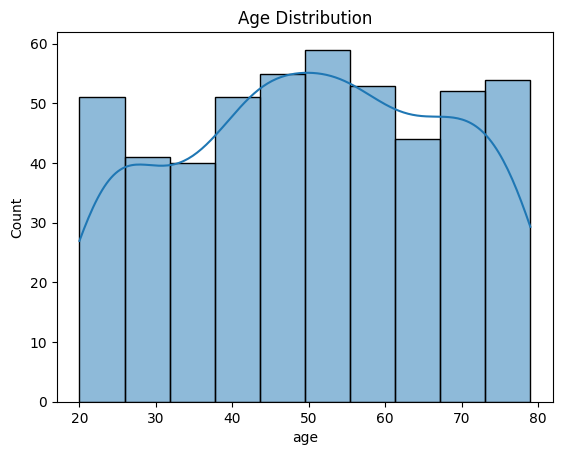

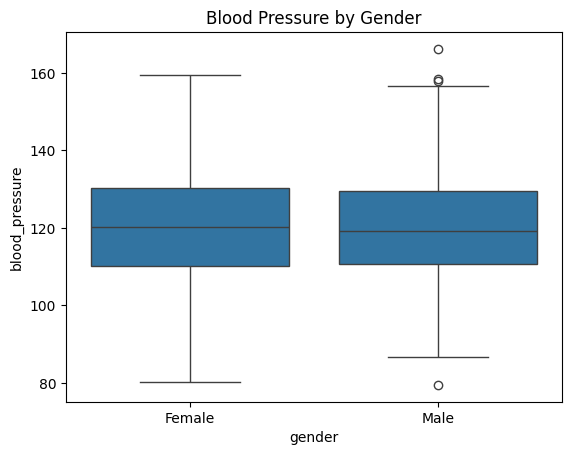

In [8]:
# Visualize Distributions of Key Features
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.boxplot(x='gender', y='blood_pressure', data=df)
plt.title("Blood Pressure by Gender")
plt.show()

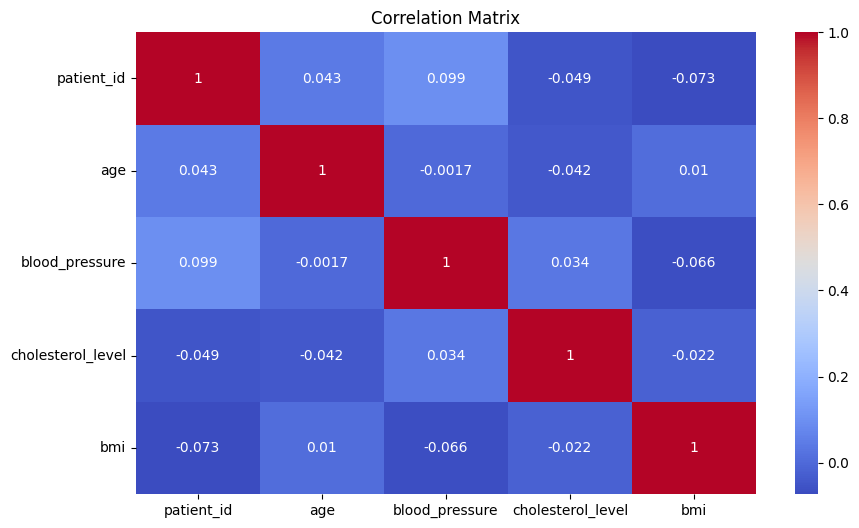

In [9]:
# Analyze Correlaions

corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

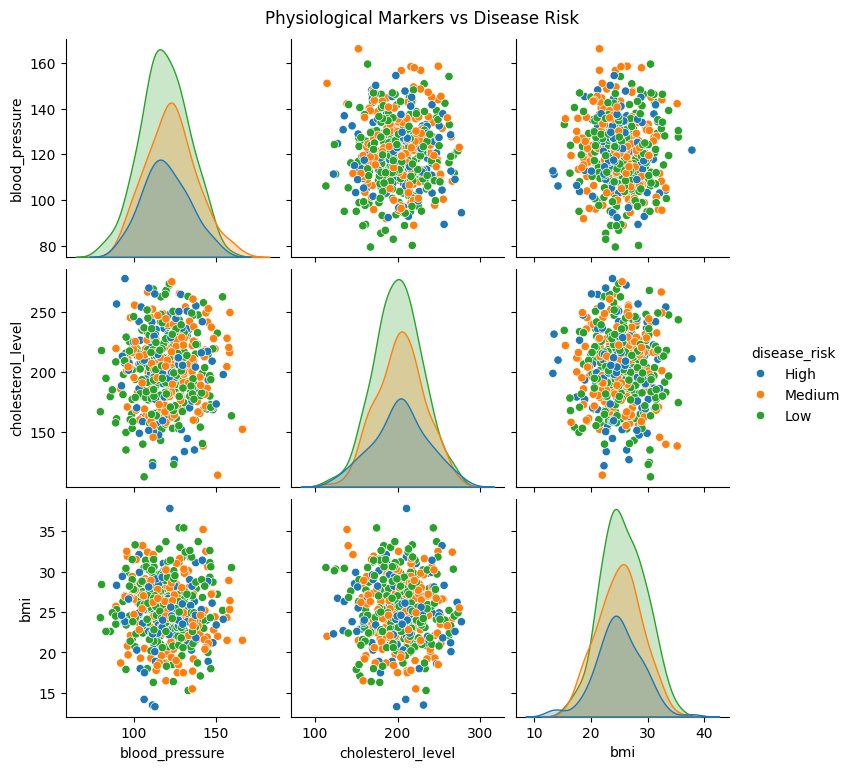

In [10]:
# Investigate Relationship Between Markers and Disease Risk
sns.pairplot(df, hue='disease_risk',
             vars=['blood_pressure', 'cholesterol_level', 'bmi'])
plt.suptitle("Physiological Markers vs Disease Risk", y=1.02)
plt.show()

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Load the dataset
df = pd.read_csv("synthetic_patient_data_v2.csv")

# Inspect to confirm all non-numeric columns
print("Columns with object (string) dtype in original DataFrame:\n", df.select_dtypes(include='object').columns)

# Identify all categorical columns (excluding the target)
categorical_cols = ['gender', 'family_history', 'smoking_status', 'cholesterol_level', 'physical_activity_level']

# One-hot encode categorical features only
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode the target column
le = LabelEncoder()
y = le.fit_transform(df['disease_risk'])

# Drop the original target column from features
X = df_encoded.drop(columns=['disease_risk'])

# Ensure all columns in X are numeric
print("Non-numeric columns in X before split:\n", X.select_dtypes(include='object').columns)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Check data types of X_train**
print("\nData types of columns in X_train:")
print(X_train.dtypes)

# Train the model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Columns with object (string) dtype in original DataFrame:
 Index(['gender', 'smoking_status', 'physical_activity_level', 'family_history',
       'disease_risk'],
      dtype='object')
Non-numeric columns in X before split:
 Index([], dtype='object')

Data types of columns in X_train:
patient_id                            int64
age                                   int64
blood_pressure                      float64
bmi                                 float64
gender_Male                            bool
                                     ...   
cholesterol_level_273.2                bool
cholesterol_level_274.8                bool
cholesterol_level_277.4                bool
physical_activity_level_Low            bool
physical_activity_level_Moderate       bool
Length: 427, dtype: object
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        19
         Low       0.49      0.76      0.59        49
      Medium       0.30      0.22      0